In [1]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:04<00:00, 15.3MB/s]



In [2]:
!unzip /content/fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.layers import Dense
from keras.layers import Flatten
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from keras import Sequential

In [4]:
conv_base = VGG16( ## create the vgg16 convolutional base and vgg16 is a moedl
    weights = 'imagenet', ## uses pre-trained imagenet weights
    include_top = False, ### removes the original classification layers
    input_shape = (150,150,3) ## set input range size to 150X150 with 3 color channels
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
conv_base.trainable = True # all vgg16 layers trainbale from strats
set_trainable = False # starts by keeping the layers false
for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
      layer.trainable = True
  else:
    layer.trainable = False
for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [6]:
model = Sequential()
model.add(conv_base) ## adds the VGG16 convolutional base
model.add(Flatten()) ## converts the feature map into a 1D vector
model.add(Dense(256, activation = 'relu')) ## adds a fully connected layer with 256 neuroan
model.add(Dense(7, activation = 'softmax'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,895 (64.14 MB)

 Trainable params: 9,178,631 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [8]:
batch_size = 32 ## sets the number of images processed in each batch
train_datagen = ImageDataGenerator(
    rescale = 1./255, ### scales pixecl values from 0-255 tp 0-1
    shear_range = 0.2, ### applies random shearing to image
    zoom_range = 0.2, ### applies random zooming to image
    horizontal_flip = True ### randomly flips image horizantally
)

In [9]:
test_datagen = ImageDataGenerator(rescale = 1./255)

In [10]:
train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size = (150,150),
    batch_size = batch_size,
    class_mode = 'categorical'  ## set binary classifications for cates and dogs
)

Found 28709 images belonging to 7 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
    '/content/test',  ## path
    target_size = (150,150), ## resize image 50x150 pixcels
    batch_size = batch_size,  ## loads 32 images in each others
    class_mode = 'categorical'  ## set binary classifications for cates and dogs
)

Found 7178 images belonging to 7 classes.


In [12]:
model.compile(
    optimizer = keras.optimizers.RMSprop(learning_rate = 1e-5),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [14]:
history = model.fit(
    train_generator,
    epochs = 3,
    validation_data = test_generator
)

Epoch 1/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 231s 258ms/step - accuracy: 0.5336 - loss: 1.2341 - val_accuracy: 0.5474 - val_loss: 1.1802
Epoch 2/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 233s 260ms/step - accuracy: 0.5638 - loss: 1.1529 - val_accuracy: 0.5680 - val_loss: 1.1357
Epoch 3/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 232s 258ms/step - accuracy: 0.5892 - loss: 1.0966 - val_accuracy: 0.5844 - val_loss: 1.1063


In [15]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

<IPython.core.display.Javascript object>

Saved to photo.jpg


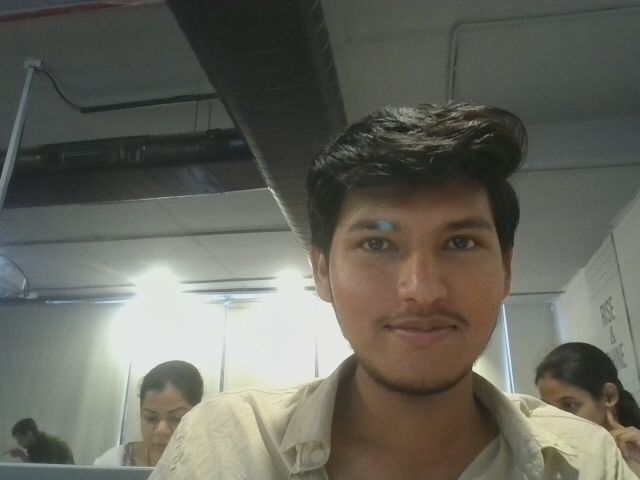

In [17]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

In [27]:
img = image.load_img(
    '/content/angry2.jpeg',
    target_size = (150,150)
)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis = 0)
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction[0])
class_names = [
    'angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sunprise'
]
print("Predicted class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted class: angry
